In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [6]:
df = pd.read_csv('clean_breast.csv', sep=';')

df.head()

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


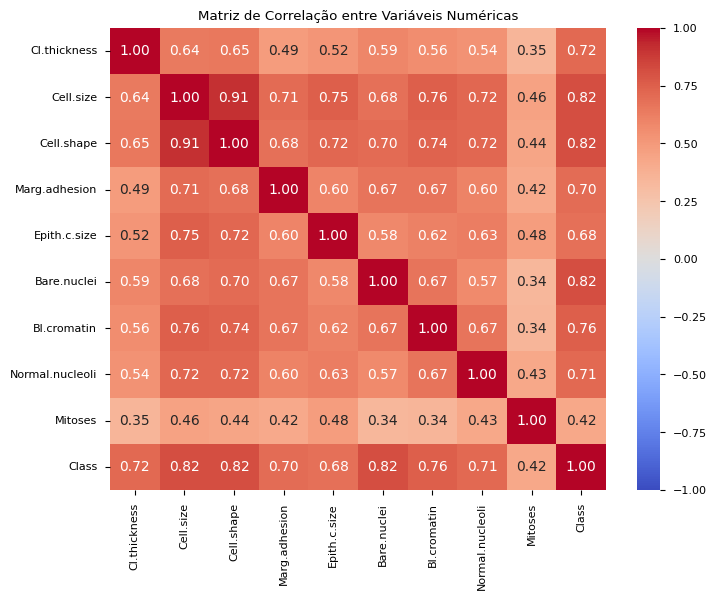

In [7]:
colunas_numericas = df.select_dtypes(include=[np.number])
matriz_corr = colunas_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.savefig("heatmap.pdf", format="pdf", bbox_inches='tight')

In [21]:
X = df[['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

coeficientes = pd.DataFrame({
    'Atributo': X.columns,
    'Impacto na Classificação': modelo.coef_[0]
})

print(coeficientes)

          Atributo  Impacto na Classificação
0     Cl.thickness                  0.539437
1        Cell.size                  0.023970
2       Cell.shape                  0.408199
3    Marg.adhesion                  0.211913
4     Epith.c.size                  0.101202
5      Bare.nuclei                  0.433610
6      Bl.cromatin                  0.383689
7  Normal.nucleoli                  0.010350
8          Mitoses                  0.329996


In [26]:
def calcular_metricas(y_true, y_pred, nome_modelo):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "Modelo": nome_modelo,
        "R²": f"{r2:.4f}",
        "MAE": f"{mae:,.2f}",
        "RMSE": f"{rmse:,.2f}"
    }

y_pred = modelo.predict(X_test)

resultados = calcular_metricas(y_test, y_pred, "Regressão Logística")

df_resultados = pd.DataFrame([resultados])
print(df_resultados)

                Modelo      R²   MAE  RMSE
0  Regressão Logística  0.8363  0.04  0.19


In [ ]:
# teste do modelo

novo_paciente = pd.DataFrame([{
    'Cl.thickness': 2,
    'Cell.size': 3,
    'Cell.shape': 1,
    'Marg.adhesion': 4,
    'Epith.c.size': 2,
    'Bare.nuclei': 3,
    'Bl.cromatin': 2,
    'Normal.nucleoli': 2,
    'Mitoses': 1
}])

classificacao_prevista = modelo.predict(novo_paciente)[0]

print(f"Legenda: (0=benigno/ausente | 1=maligno)\n\nClassificação prevista: {classificacao_prevista}")

Classificação prevista: (0=benigno/ausente | 1=maligno) 0
